In [28]:
import numpy as np
from numpy import random
import matplotlib.pyplot as plt
%matplotlib inline

In [88]:
def propensity(k,x,y):
    '''Calculate the propersity of a reaction
    
    parameters
    ----------
    k:int
      reaction constant
    x:int
      molecular number of first reactant
    y:int
      molecular number of first reactant
      
    Returns
    -------
    out: int
       propensity of a reaction
    '''
    return k*x*y

def reaction1(x,y,z):   #reaction 1,2,5: X+Y->Z
    '''Calculate the molecular number change of reaction type 1:X+Y->Z 
       (two reactants and one product)
    
    parameters
    ----------
    x:int
      molecular number of first reactant
    y:int
      molecular number of second reactant
    z:int
      molecular number of first product
      
    Returns
    -------
    out: int
       molecular numbers of reactants and product after the reaction has occurred once
    '''
    
    if x>0 and y>0 and z>0:     
        x=x-1 # x -= 1
        y=y-1
        z=z+1 # z += 1
    return x,y,z
    
def reaction2(a,b,c,d):   #reaction 3: a+b->c+d
    '''Calculate the molecular number change of reaction type 2:A+B->C+D
       (two reactants and two products)
    
    parameters
    ----------
    a:int
      molecular number of first reactant
    b:int
      molecular number of second reactant
    c:int
      molecular number of first product
    d:int
      molecular number of second product
      
    Returns
    -------
    out: int
       molecular numbers of reactants and products after the reaction has occurred once
    '''
    if a>0 and b>0 and c>0 and d>0:
        a=a-1
        b=b-1
        c=c+1
        d=d+1
    return a,b,c,d
    
def reaction3(e,f,g):   #reaction 4: E->F+G
    '''Calculate the molecular number change of reaction type 3:E->F+G
       (one reactant and two products)
    
    parameters
    ----------
    e:int
      molecular number of reactant
    f:int
      molecular number of first product
    g:int
      molecular number of second product
      
    Returns
    -------
    out: int
       molecular numbers of reactants and products after the reaction has occurred once
    '''
    if e>0 and f>0 and g>0:
        e=e-1
        f=f+1
        g=g+1
    return e,f,g

def chemicalsystem(a,b,c,d,e,f,g,k1,k2,k3,k4,k5,t1,t2): 
    '''Use the Direct Method to simulate the 5 reactions provided in Gibson et al
    
    parameters
    ----------
    a~g:int
      molecular number of all the 7 chemicals (A~G) involved in the 5 reactions
    k1~k5:int
      reaction constants of 5 chemical reactions
    t1:int
      simulation start time
    t2:int
      simulation ending time
      
    Returns
    -------
    out: figure
       graphical representation of the simulation from t1 to t2
    '''        
    t0=t1
    t1_list=[]
    chemical_list=[]
    
    while t1<t2:
        prop1=propensity(k1,a,b)
        prop2=propensity(k2,b,c)
        prop3=propensity(k3,d,e)
        prop4=propensity(k4,f,1)
        prop5=propensity(k5,e,g)    
    
        specieslist=[a,b,c,d,e,f,g]
        propensitylist=[prop1,prop2,prop3,prop4,prop5]
        sumprop=sum(propensitylist)
        problist=[]
        for i in propensitylist:
            problist.append(i/sumprop)
#         print(problist)
        u=random.choice(np.arange(0,5),p=problist)
        tou=random.exponential(1/sumprop)
    
        if u==0:
            a, b, c = reaction1(a,b,c)
        elif u==1:
            b, c, d = reaction1(b,c,d)
        elif u==2:
            d,e,e,f = reaction2(d,e,e,f)
        elif u==3:
            e,f,g = reaction3(e,f,g)
        else:
            e,g,a = reaction1(e,g,a)
       
        t1=t1+tou
        t1_list.append(t1)
        chemical_list.append(specieslist)
        
    a_list=[]
    for i in chemical_list:
        a_list.append(i[0])

    b_list=[]
    for i in chemical_list:
        b_list.append(i[1])
        
    c_list=[]
    for i in chemical_list:
        c_list.append(i[2])
   
    d_list=[]
    for i in chemical_list:
        d_list.append(i[3])
    
    e_list=[]
    for i in chemical_list:
        e_list.append(i[4])
        
    f_list=[]
    for i in chemical_list:
        f_list.append(i[5])
        
    g_list=[]
    for i in chemical_list:
        g_list.append(i[6])
    
    
    a_array=np.array(a_list)
    b_array=np.array(b_list)
    c_array=np.array(c_list)
    d_array=np.array(d_list)
    e_array=np.array(e_list)
    f_array=np.array(f_list)
    g_array=np.array(g_list)
    
    count_a=len(a_array)
    while count_a!=0:
        ax=a_array[count_a - 1]-a_array[len(a_array) - 1]
        count_a-=1
        if ax!=0:
            index_a= count_a
            break
    a_stabletime=t1_list[index_a]
    print(count_a)
    print(len(a_array))
    print(a_stabletime)
       
    count_b=len(b_array)
    while count_b!=0:
        bx=b_array[count_b - 1]-b_array[len(b_array) - 1]
        count_b-=1
        if bx!=0:
            index_b= count_b
            break
    b_stabletime=t1_list[index_b]
    print(count_b)
    print(len(b_array))
    print(b_stabletime)
    
    count_c=len(c_array)
    while count_c!=0:
        cx=c_array[count_c - 1]-c_array[len(c_array) - 1]
        count_c-=1
        if cx!=0:
            index_c= count_c
            break
    c_stabletime=t1_list[index_c]
    print(count_c)
    print(len(c_array))
    print(c_stabletime)       
            
    count_d=len(d_array)
    while count_d!=0:
        dx=d_array[count_d - 1]-d_array[len(d_array) - 1]
        count_d-=1
        if dx!=0:
            index_d= count_d
            break
    d_stabletime=t1_list[index_d]
    print(count_d)
    print(len(d_array))
    print(d_stabletime)    
    
    count_e=len(e_array)
    while count_e!=0:
        ex=e_array[count_e - 1]-e_array[len(e_array) - 1]
        count_e-=1
        if ex!=0:
            index_e= count_e
            break
    e_stabletime=t1_list[index_e]
    print(count_e)
    print(len(e_array))
    print(e_stabletime)    
    
    count_f=len(f_array)
    while count_f!=0:
        fx=f_array[count_f - 1]-f_array[len(f_array) - 1]
        count_f-=1
        if fx!=0:
            index_f= count_f
            break
    f_stabletime=t1_list[index_f]
    print(count_f)
    print(len(f_array))
    print(f_stabletime)    
    
    count_g=len(g_array)
    while count_g!=0:
        gx=g_array[count_g - 1]-g_array[len(g_array) - 1]
        count_g-=1
        if gx!=0:
            index_g= count_g
            break
    g_stabletime=t1_list[index_g]
    print(count_g)
    print(len(g_array))
    print(g_stabletime)    
            
    stabletime_list=[a_stabletime, b_stabletime, c_stabletime, d_stabletime, e_stabletime, f_stabletime, g_stabletime]
    stabletime_array=np.array(stabletime_list)
        
    x=t1_list
    y=chemical_list
    m=np.array(x)
    n=np.array(y)
    plt.plot(m,n)
    # print(fig)
    plt.xlim(t0,t0+0.5)
    plt.title('Simulation of 5 chemical reactions')
    plt.xlabel('Time/s')
    plt.ylabel('Molecular No.')
    plt.legend(['A', 'B', 'C', 'D', 'E', 'F', 'G'])
    plt.show()
    
    return stabletime_array

97
9722
1.5553555094075098
97
9722
1.5553555094075098
97
9722
1.5553555094075098
41
9722
1.0668519846788254
41
9722
1.0668519846788254
41
9722
1.0668519846788254
26
9722
1.0383930482915338


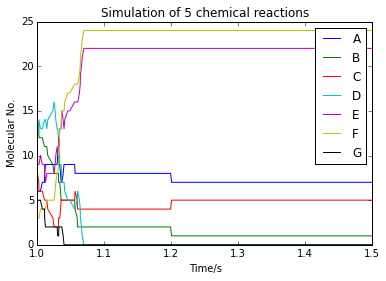

array([ 1.55535551,  1.55535551,  1.55535551,  1.06685198,  1.06685198,
        1.06685198,  1.03839305])

In [85]:
chemicalsystem(6,14,8,12,9,3,5,1,2,3,4,5,1,100)

141
8847
1.907301688546849
141
8847
1.907301688546849
141
8847
1.907301688546849
35
8847
1.076847911090054
35
8847
1.076847911090054
35
8847
1.076847911090054
10
8847
1.017008407826034


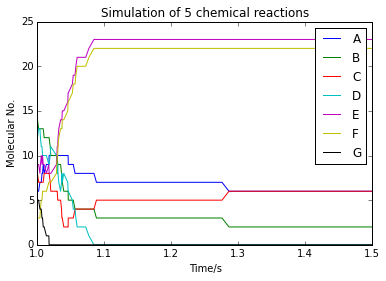

45
10985
1.083176066994167
45
10985
1.083176066994167
45
10985
1.083176066994167
42
10985
1.073890956487081
48
10985
1.1046946952053145
48
10985
1.1046946952053145
48
10985
1.1046946952053145


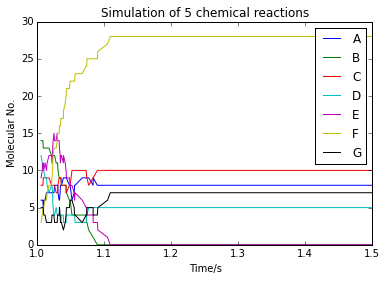

42
8699
1.1102820956843156
42
8699
1.1102820956843156
42
8699
1.1102820956843156
38
8699
1.0850265061012836
38
8699
1.0850265061012836
38
8699
1.0850265061012836
14
8699
1.0196279274196358


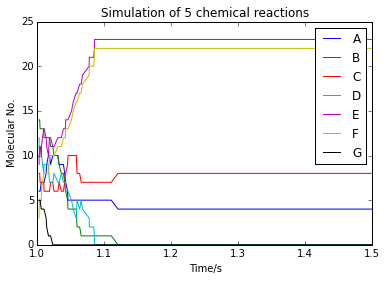

60
15065
1.1383423682659675
53
15065
1.1019580418810715
53
15065
1.1019580418810715
57
15065
1.1215992471682819
62
15065
1.1450376845526418
62
15065
1.1450376845526418
62
15065
1.1450376845526418


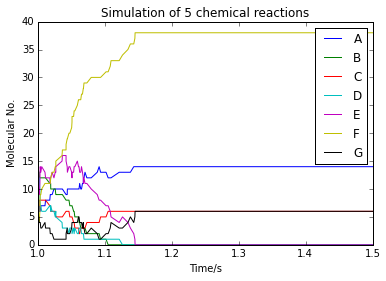

79
11575
1.2708965487606108
79
11575
1.2708965487606108
79
11575
1.2708965487606108
35
11575
1.0456626118318237
50
11575
1.081737739245929
46
11575
1.0722554677975233
50
11575
1.081737739245929


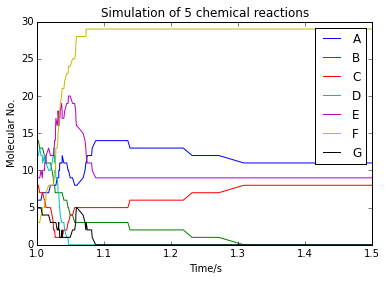

56
14429
1.1379260277386256
57
14429
1.1425340467648581
57
14429
1.1425340467648581
57
14429
1.1425340467648581
58
14429
1.1481928394340388
58
14429
1.1481928394340388
58
14429
1.1481928394340388


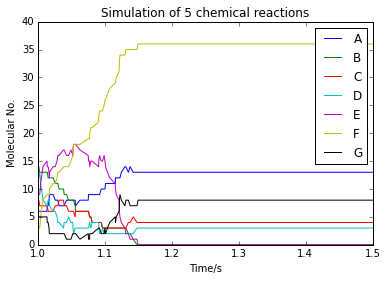

63
11992
1.1672062164845698
63
11992
1.1672062164845698
63
11992
1.1672062164845698
46
11992
1.0800891006473936
51
11992
1.0930041655126357
51
11992
1.0930041655126357
51
11992
1.0930041655126357


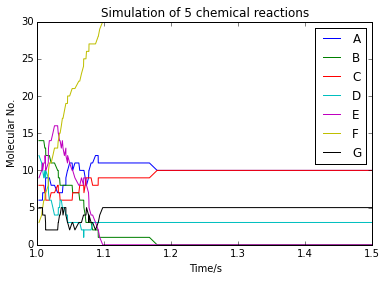

79
9742
1.4889416105434927
79
9742
1.4889416105434927
79
9742
1.4889416105434927
38
9742
1.054333529988407
38
9742
1.054333529988407
38
9742
1.054333529988407
29
9742
1.0310960390654464


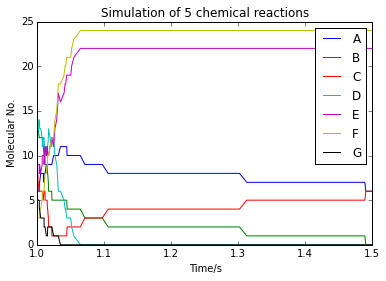

81
8938
1.4040927949998954
81
8938
1.4040927949998954
81
8938
1.4040927949998954
43
8938
1.1178565637514268
43
8938
1.1178565637514268
43
8938
1.1178565637514268
23
8938
1.0277792497794829


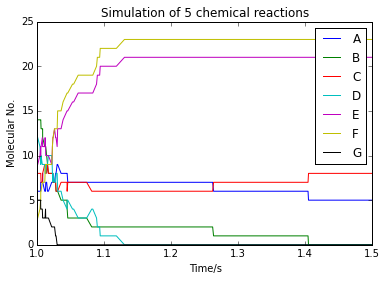

93
8005
1.4534047161098003
93
8005
1.4534047161098003
93
8005
1.4534047161098003
28
8005
1.034453590461856
28
8005
1.034453590461856
28
8005
1.034453590461856
16
8005
1.0209769383696563


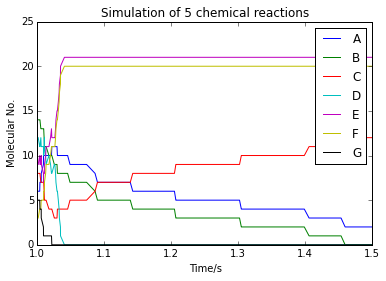

27
10009
1.0360666709596154
45
10009
1.1090918193281798
45
10009
1.1090918193281798
51
10009
1.1556070546887975
51
10009
1.1556070546887975
51
10009
1.1556070546887975
27
10009
1.0360666709596154


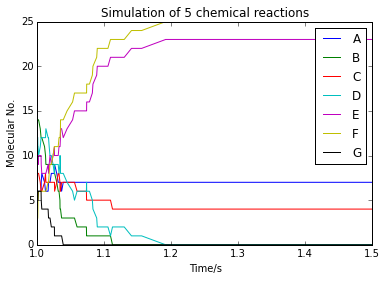

26
9505
1.0313352616958873
39
9505
1.0634571815762708
39
9505
1.0634571815762708
45
9505
1.0969939042006154
45
9505
1.0969939042006154
45
9505
1.0969939042006154
19
9505
1.0220782237069133


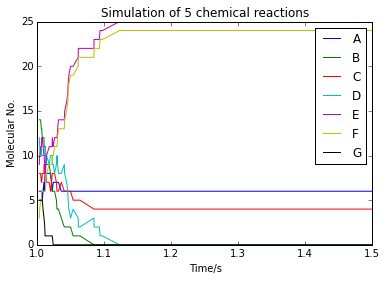

56
14826
1.1191542764427023
60
14826
1.1410806467908516
60
14826
1.1410806467908516
60
14826
1.1410806467908516
59
14826
1.1279319409252413
59
14826
1.1279319409252413
59
14826
1.1279319409252413


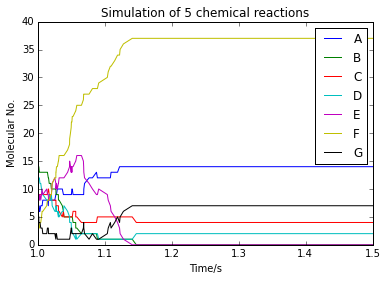

64
14349
1.161932597108528
64
14349
1.161932597108528
64
14349
1.161932597108528
43
14349
1.0820971530131533
56
14349
1.117155733376009
56
14349
1.117155733376009
56
14349
1.117155733376009


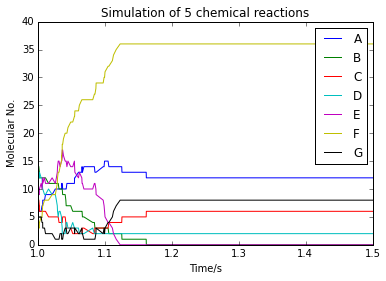

106
9102
1.7941256017223797
106
9102
1.7941256017223797
106
9102
1.7941256017223797
37
9102
1.0684083048117134
37
9102
1.0684083048117134
37
9102
1.0684083048117134
24
9102
1.0324850113568387


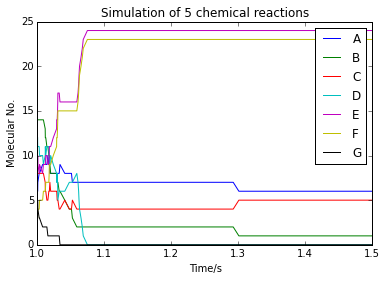

64
9317
1.3360860850508627
64
9317
1.3360860850508627
64
9317
1.3360860850508627
40
9317
1.1101083700173633
40
9317
1.1101083700173633
40
9317
1.1101083700173633
28
9317
1.0412164349665278


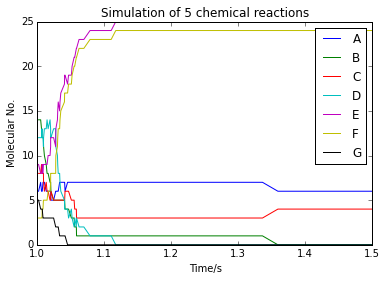

95
9226
1.58194734717757
95
9226
1.58194734717757
95
9226
1.58194734717757
42
9226
1.094255479012162
42
9226
1.094255479012162
42
9226
1.094255479012162
18
9226
1.020719131587687


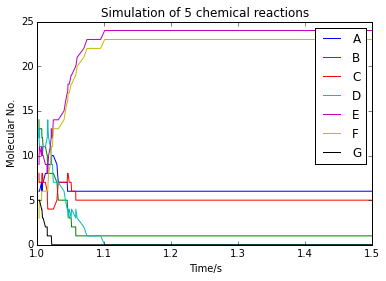

49
8741
1.19127613289829
49
8741
1.19127613289829
49
8741
1.19127613289829
36
8741
1.0869053015342711
36
8741
1.0869053015342711
36
8741
1.0869053015342711
17
8741
1.0288886084170674


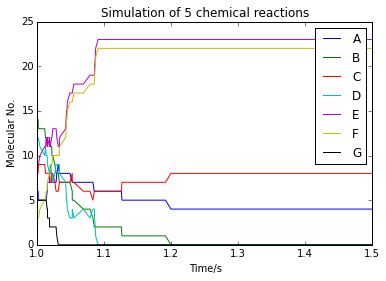

404
7345
4.176467242754016
404
7345
4.176467242754016
404
7345
4.176467242754016
26
7345
1.0497437236747922
26
7345
1.0497437236747922
26
7345
1.0497437236747922
20
7345
1.0379274976944277


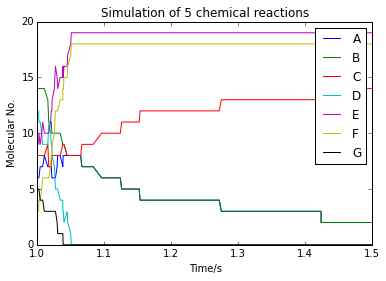

52
8692
1.2420984532621837
52
8692
1.2420984532621837
52
8692
1.2420984532621837
33
8692
1.0552155588855834
33
8692
1.0552155588855834
33
8692
1.0552155588855834
25
8692
1.0326441815828185


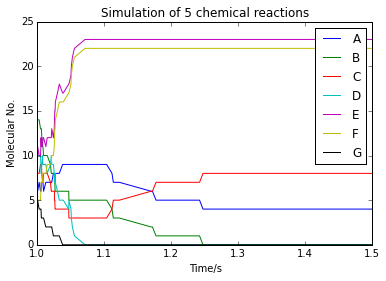

62
9127
1.2501020069122855
62
9127
1.2501020069122855
62
9127
1.2501020069122855
29
9127
1.0477215166893155
36
9127
1.0772668267965408
31
9127
1.048658671358315
36
9127
1.0772668267965408


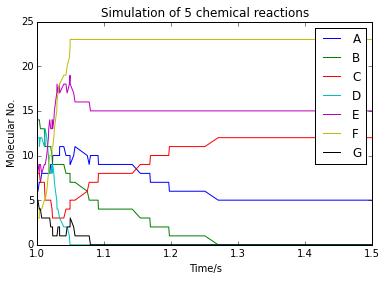

60
14380
1.0959304631139701
60
14380
1.0959304631139701
60
14380
1.0959304631139701
52
14380
1.071873950788028
59
14380
1.0957006657077188
59
14380
1.0957006657077188
59
14380
1.0957006657077188


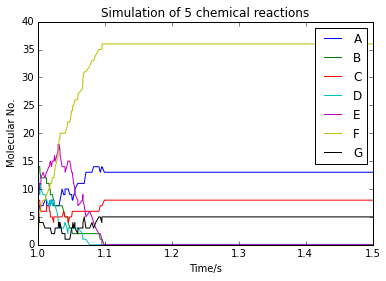

68
13921
1.2016893885801616
68
13921
1.2016893885801616
68
13921
1.2016893885801616
47
13921
1.1187190224015235
59
13921
1.1514002111899808
59
13921
1.1514002111899808
59
13921
1.1514002111899808


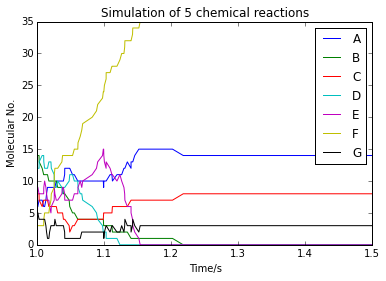

78
7894
1.5063497141059323
78
7894
1.5063497141059323
78
7894
1.5063497141059323
28
7894
1.0724047656149256
28
7894
1.0724047656149256
28
7894
1.0724047656149256
20
7894
1.0311757542000999


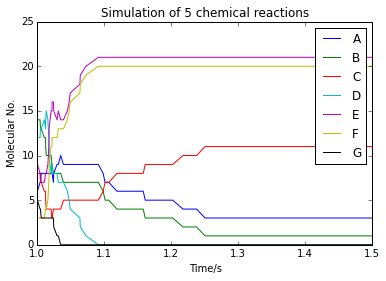

60
8724
1.3121817694555882
60
8724
1.3121817694555882
60
8724
1.3121817694555882
35
8724
1.0704232003397054
35
8724
1.0704232003397054
35
8724
1.0704232003397054
23
8724
1.0396594389175655


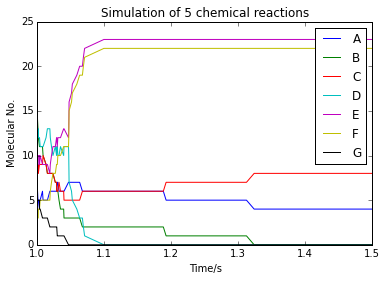

24
9905
1.03371623773843
42
9905
1.0937715638054304
42
9905
1.0937715638054304
44
9905
1.1021355875310397
44
9905
1.1021355875310397
44
9905
1.1021355875310397
24
9905
1.03371623773843


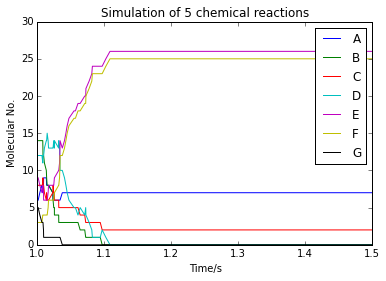

158
7814
2.0093201749214207
158
7814
2.0093201749214207
158
7814
2.0093201749214207
35
7814
1.0752524966924861
35
7814
1.0752524966924861
35
7814
1.0752524966924861
17
7814
1.0226286011529968


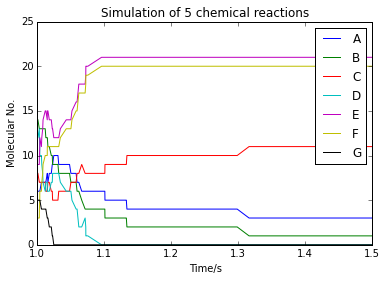

63
9962
1.304819909443112
63
9962
1.304819909443112
63
9962
1.304819909443112
44
9962
1.115088273322295
44
9962
1.115088273322295
44
9962
1.115088273322295
35
9962
1.059082519752132


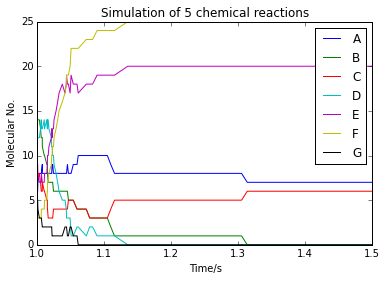

42
10598
1.0969636469144526
43
10598
1.0978588133088314
43
10598
1.0978588133088314
50
10598
1.1169586723258318
50
10598
1.1169586723258318
50
10598
1.1169586723258318
42
10598
1.0969636469144526


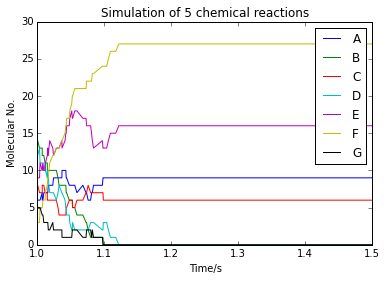

47
9634
1.1610469601445763
47
9634
1.1610469601445763
47
9634
1.1610469601445763
45
9634
1.1050785236888987
45
9634
1.1050785236888987
45
9634
1.1050785236888987
24
9634
1.023478805585639


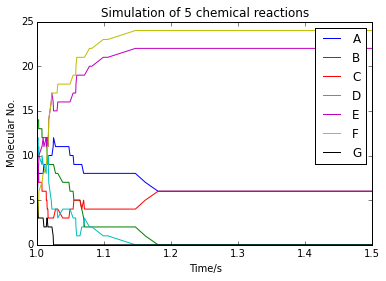

52
12789
1.1007251448760038
55
12789
1.1273384523082994
55
12789
1.1273384523082994
55
12789
1.1273384523082994
56
12789
1.131566973930274
56
12789
1.131566973930274
56
12789
1.131566973930274


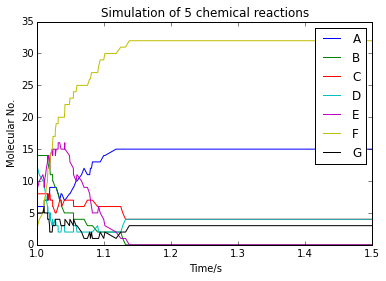

99
9370
1.4771672008998833
99
9370
1.4771672008998833
99
9370
1.4771672008998833
39
9370
1.053542050332572
39
9370
1.053542050332572
39
9370
1.053542050332572
35
9370
1.0386168473616666


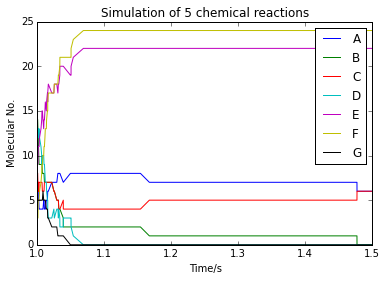

52
12574
1.1258577712402746
59
12574
1.169795308332135
59
12574
1.169795308332135
59
12574
1.169795308332135
51
12574
1.118276096816139
51
12574
1.118276096816139
51
12574
1.118276096816139


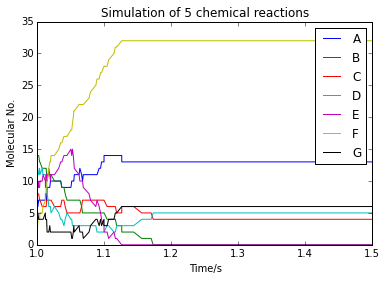

56
9896
1.1902870297287713
56
9896
1.1902870297287713
56
9896
1.1902870297287713
53
9896
1.1698918675183414
53
9896
1.1698918675183414
53
9896
1.1698918675183414
31
9896
1.0428718945621005


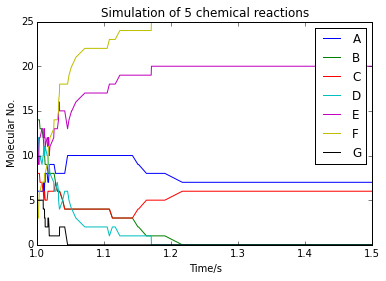

97
9860
1.4612078536478932
97
9860
1.4612078536478932
97
9860
1.4612078536478932
41
9860
1.1166744213035011
41
9860
1.1166744213035011
41
9860
1.1166744213035011
37
9860
1.0917887691021027


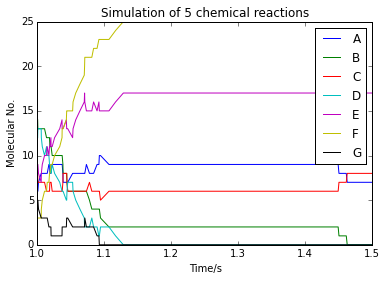

63
9471
1.2583870906442456
63
9471
1.2583870906442456
63
9471
1.2583870906442456
41
9471
1.073987018051307
41
9471
1.073987018051307
41
9471
1.073987018051307
25
9471
1.0424582258082251


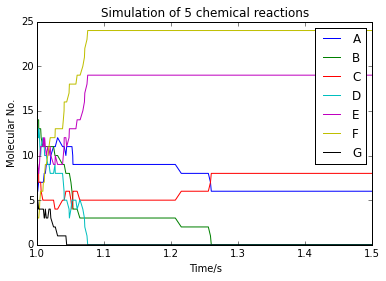

74
10118
1.3164284579503873
74
10118
1.3164284579503873
74
10118
1.3164284579503873
56
10118
1.1468817899336297
56
10118
1.1468817899336297
56
10118
1.1468817899336297
26
10118
1.0372089282346353


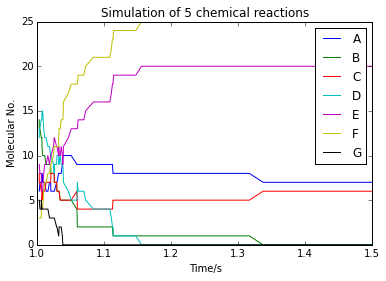

51
10012
1.186306166100218
51
10012
1.186306166100218
51
10012
1.186306166100218
43
10012
1.0861864734880906
43
10012
1.0861864734880906
43
10012
1.0861864734880906
32
10012
1.0543307230947712


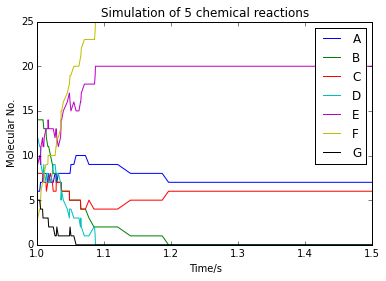

64
15207
1.1883730153758718
64
15207
1.1883730153758718
64
15207
1.1883730153758718
50
15207
1.1131764398046857
61
15207
1.173621574123132
61
15207
1.173621574123132
61
15207
1.173621574123132


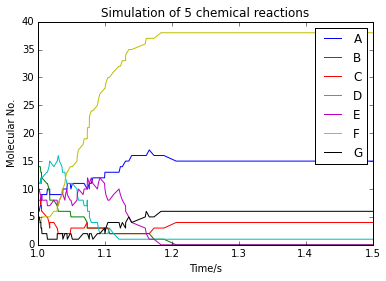

126
9210
1.9163341696875429
126
9210
1.9163341696875429
126
9210
1.9163341696875429
42
9210
1.1285732889097484
42
9210
1.1285732889097484
42
9210
1.1285732889097484
14
9210
1.021853505676229


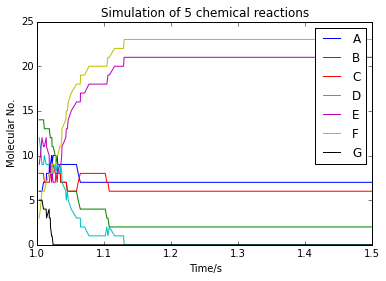

38
9161
1.060117759530807
38
9161
1.060117759530807
38
9161
1.060117759530807
46
9161
1.1026878129795012
46
9161
1.1026878129795012
46
9161
1.1026878129795012
18
9161
1.023972822628697


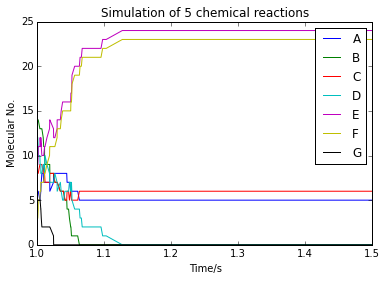

66
9179
1.3429823774132508
66
9179
1.3429823774132508
66
9179
1.3429823774132508
41
9179
1.0867089232939433
41
9179
1.0867089232939433
41
9179
1.0867089232939433
33
9179
1.0564665235174462


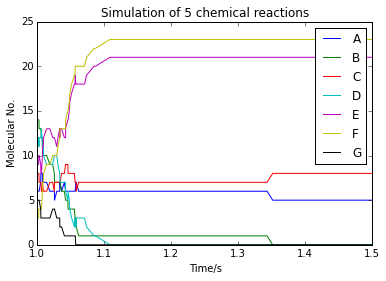

83
8966
1.360216715345841
83
8966
1.360216715345841
83
8966
1.360216715345841
38
8966
1.070124229684513
38
8966
1.070124229684513
38
8966
1.070124229684513
33
8966
1.052899270717638


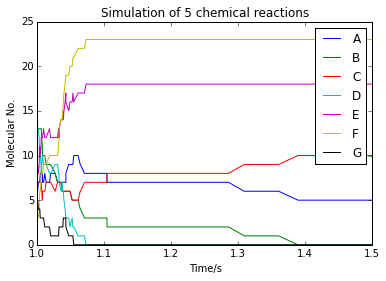

86
12003
1.275813737959901
86
12003
1.275813737959901
86
12003
1.275813737959901
21
12003
1.0338027352432486
60
12003
1.1483997163909294
60
12003
1.1483997163909294
60
12003
1.1483997163909294


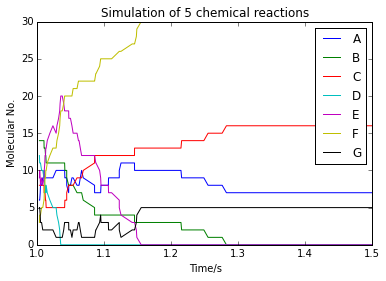

37
9170
1.0723931597026324
37
9170
1.0723931597026324
37
9170
1.0723931597026324
40
9170
1.083779501411642
40
9170
1.083779501411642
40
9170
1.083779501411642
27
9170
1.0427610521902406


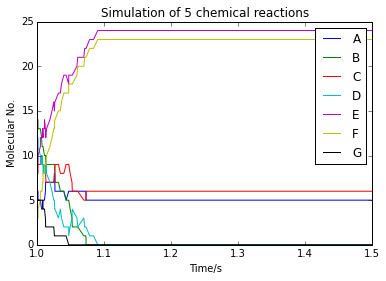

108
8816
1.8055142747517958
108
8816
1.8055142747517958
108
8816
1.8055142747517958
36
8816
1.0769327217082265
36
8816
1.0769327217082265
36
8816
1.0769327217082265
22
8816
1.0387979477765032


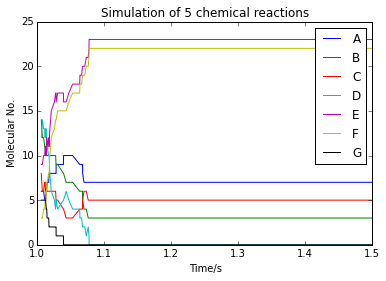

77
11137
1.2823150064926832
77
11137
1.2823150064926832
77
11137
1.2823150064926832
36
11137
1.0553045286646952
46
11137
1.1114943557705663
43
11137
1.0799924793398612
46
11137
1.1114943557705663


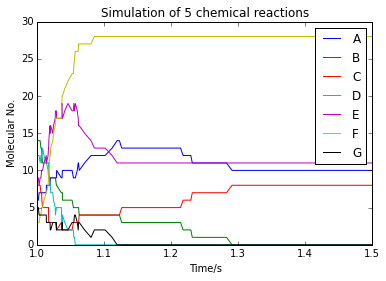

54
11823
1.1192592722667745
54
11823
1.1192592722667745
54
11823
1.1192592722667745
44
11823
1.0752508670286198
49
11823
1.0929043291027876
49
11823
1.0929043291027876
49
11823
1.0929043291027876


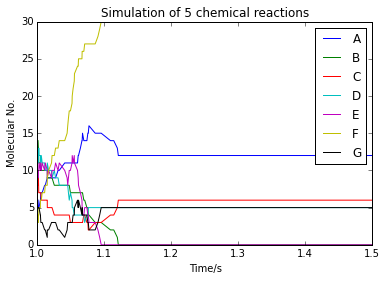

76
8870
1.4206244507910681
76
8870
1.4206244507910681
76
8870
1.4206244507910681
37
8870
1.0693246953417463
37
8870
1.0693246953417463
37
8870
1.0693246953417463
20
8870
1.0300204264883672


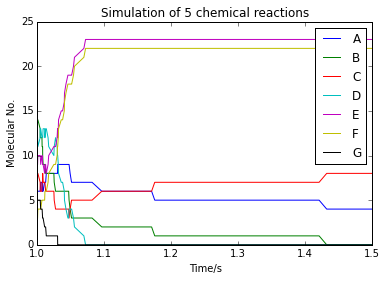

58
14239
1.1250307941845055
58
14239
1.1250307941845055
58
14239
1.1250307941845055
57
14239
1.1234664487635277
60
14239
1.149304973412937
60
14239
1.149304973412937
60
14239
1.149304973412937


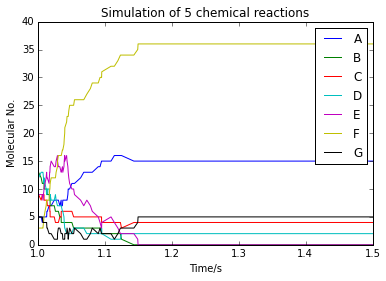

[ 1.90730169  1.08317607  1.1102821   1.13834237  1.27089655  1.13792603
  1.16720622  1.48894161  1.40409279  1.45340472  1.03606667  1.03133526
  1.11915428  1.1619326   1.7941256   1.33608609  1.58194735  1.19127613
  4.17646724  1.24209845  1.25010201  1.09593046  1.20168939  1.50634971
  1.31218177  1.03371624  2.00932017  1.30481991  1.09696365  1.16104696
  1.10072514  1.4771672   1.12585777  1.19028703  1.46120785  1.25838709
  1.31642846  1.18630617  1.18837302  1.91633417  1.06011776  1.34298238
  1.36021672  1.27581374  1.07239316  1.80551427  1.28231501  1.11925927
  1.42062445  1.12503079] [ 1.90730169  1.08317607  1.1102821   1.10195804  1.27089655  1.14253405
  1.16720622  1.48894161  1.40409279  1.45340472  1.10909182  1.06345718
  1.14108065  1.1619326   1.7941256   1.33608609  1.58194735  1.19127613
  4.17646724  1.24209845  1.25010201  1.09593046  1.20168939  1.50634971
  1.31218177  1.09377156  2.00932017  1.30481991  1.09785881  1.16104696
  1.12733845  1.4771672  

In [92]:
a_timelist=[]
b_timelist=[]
c_timelist=[]
d_timelist=[]
e_timelist=[]
f_timelist=[]
g_timelist=[]

i=1
while i<=50:
    x=chemicalsystem(6,14,8,12,9,3,5,1,2,3,4,5,1,100)
    a_timelist.append(x[0])
    b_timelist.append(x[1])
    c_timelist.append(x[2])
    d_timelist.append(x[3])
    e_timelist.append(x[4])
    f_timelist.append(x[5])
    g_timelist.append(x[6])
    i+=1

a_timearray=np.array(a_timelist)
b_timearray=np.array(b_timelist)
c_timearray=np.array(c_timelist)
d_timearray=np.array(d_timelist)
e_timearray=np.array(e_timelist)
f_timearray=np.array(f_timelist)
g_timearray=np.array(g_timelist)

print(a_timearray,b_timearray, c_timearray, d_timearray, e_timearray, f_timearray, g_timearray)